# 09 · Statistical outliers and multivariate anomaly detection

Contrast univariate statistical rules, multivariate distance diagnostics and algorithmic anomaly scores. The goal is not to label bad data, but to see where different notions of extremeness agree or disagree.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_outliers, analyze_anomalies, analyze_multivariate, analyze_pca
frame,dataset=load_tabular_demo(); features=load_feature_demo('representation_a')
out=analyze_outliers(dataset,include_flags=True); an=analyze_anomalies(features,methods=('isolation_forest','lof'),scaling='standard',random_state=42); mv=analyze_multivariate(features,scaling='standard',random_state=42); pca=analyze_pca(features,n_components=2,scaling='standard')

## Univariate flagged observations in context

findfont: Failed to find font weight semibold, now using 700.


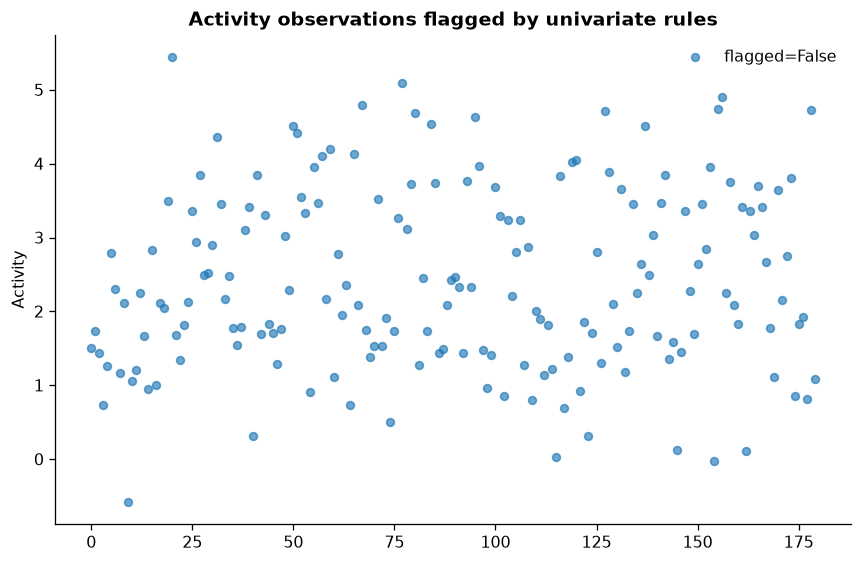

In [2]:
f=frame[['id','activity','group']].copy(); flagged=set(out.flags.query('column=="activity"').observation_id); f['flagged']=f.id.isin(flagged); fig,ax=plt.subplots(figsize=(7.6,5));
for label,sub in f.groupby('flagged'): ax.scatter(np.arange(len(sub)),sub.activity,label=f'flagged={label}',alpha=.65,s=24)
ax.set_ylabel('Activity'); ax.set_title('Activity observations flagged by univariate rules'); ax.legend(); finish(fig); plt.show()

## Anomaly-score distributions

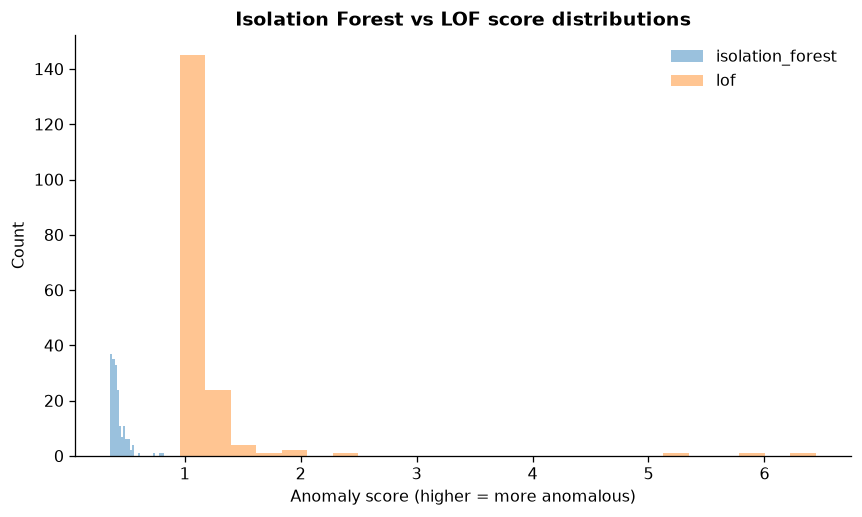

In [3]:
fig,ax=plt.subplots(figsize=(7.6,4.6));
for method,sub in an.scores.groupby('method'): ax.hist(sub.anomaly_score,bins=25,alpha=.45,label=method)
ax.set_xlabel('Anomaly score (higher = more anomalous)'); ax.set_ylabel('Count'); ax.set_title('Isolation Forest vs LOF score distributions'); ax.legend(); finish(fig); plt.show()

## Method agreement

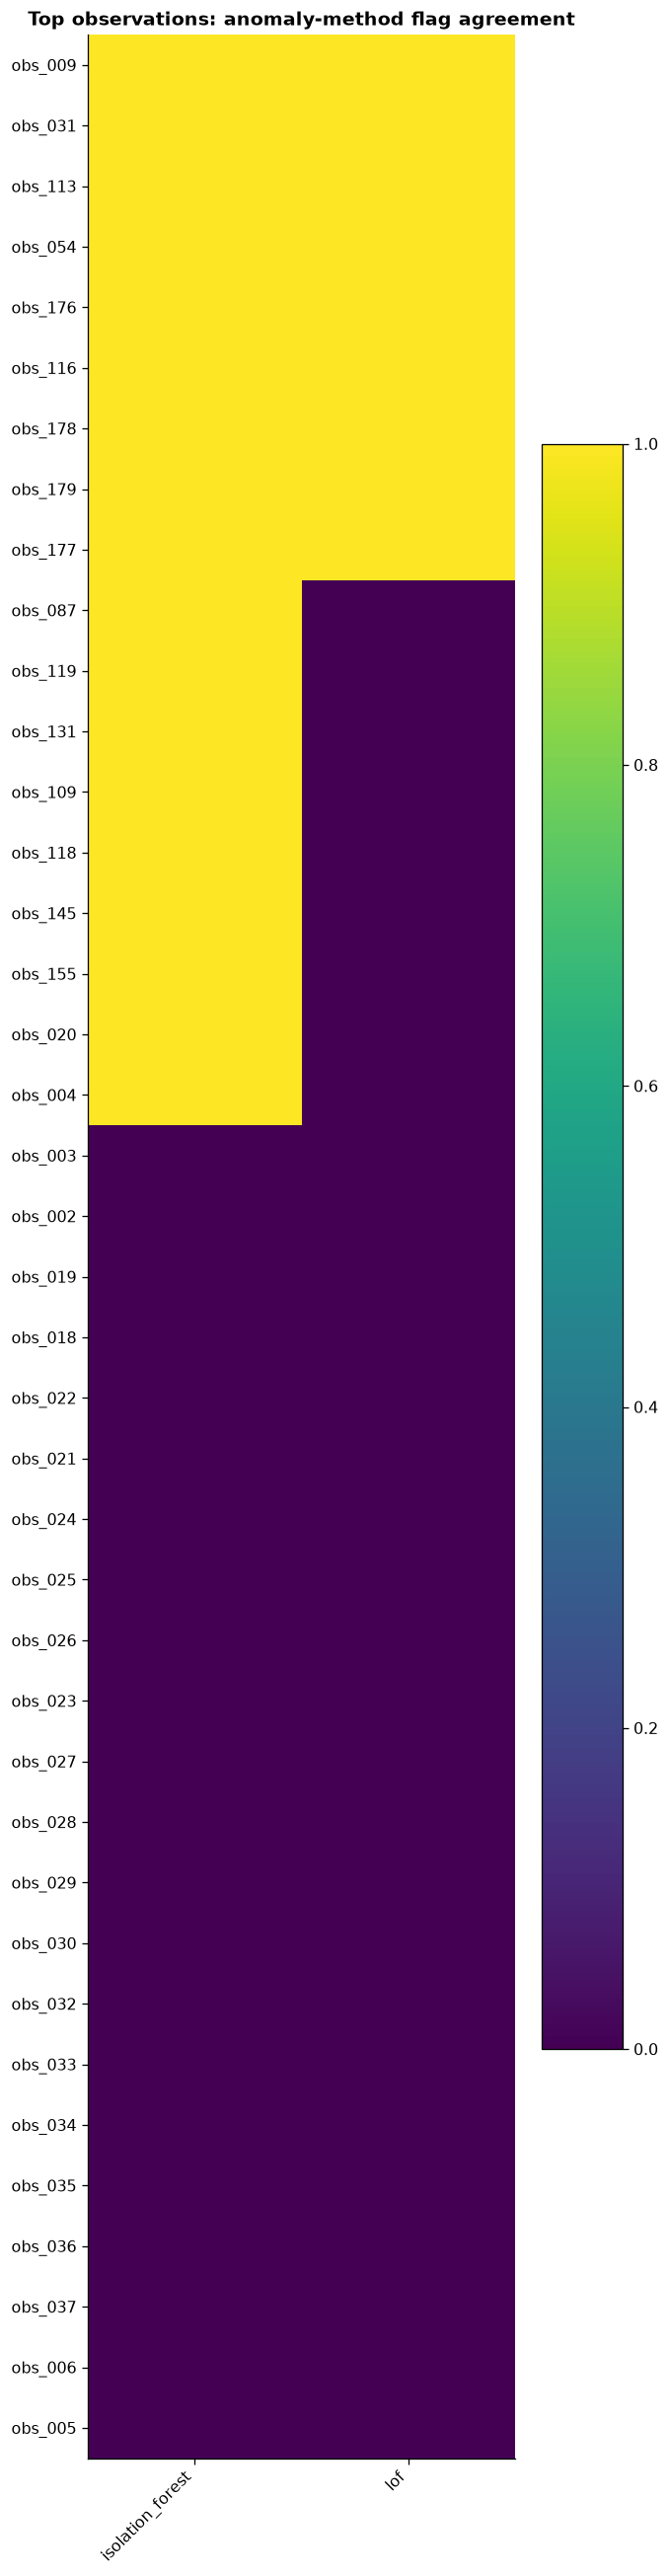

In [4]:
anomaly_agreement(an.scores,title='Top observations: anomaly-method flag agreement'); plt.show()

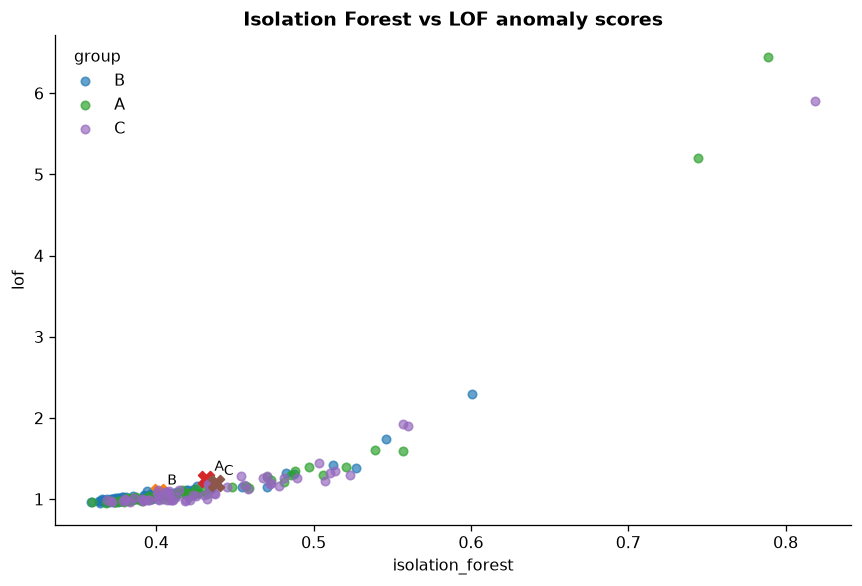

In [5]:
wide=an.scores.pivot(index='observation_id',columns='method',values='anomaly_score').dropna(); scatter_by_group(wide.reset_index().assign(group=frame.set_index('id').loc[wide.index,'group'].values),x='isolation_forest',y='lof',group='group',title='Isolation Forest vs LOF anomaly scores',fit_lines=False); plt.show()

## Anomalies overlaid on PCA

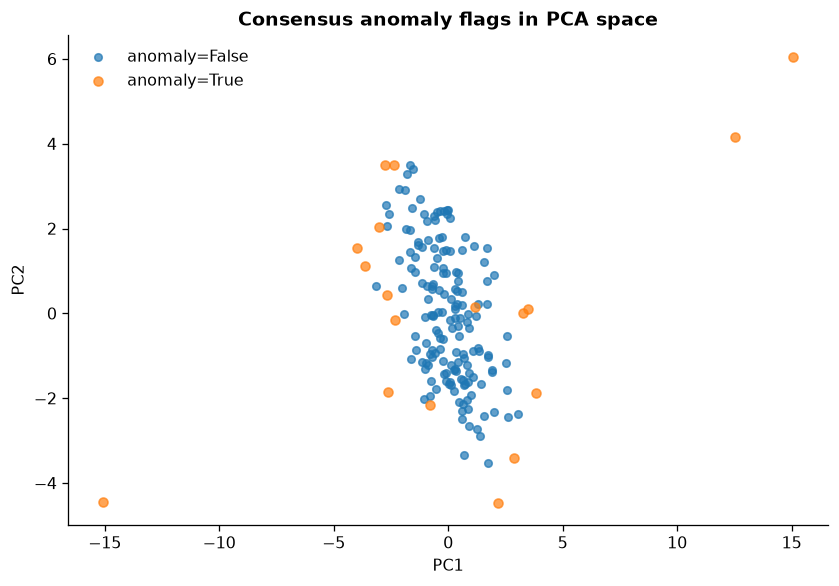

In [6]:
flags=an.scores.groupby('observation_id').is_flagged.any().rename('anomaly').reset_index(); merged=pca.scores.merge(flags,on='observation_id'); fig,ax=plt.subplots(figsize=(7.4,5.2));
for label,sub in merged.groupby('anomaly'): ax.scatter(sub.PC1,sub.PC2,label=f'anomaly={label}',alpha=.7,s=32 if label else 22)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Consensus anomaly flags in PCA space'); ax.legend(); finish(fig); plt.show()

## Classical vs robust Mahalanobis

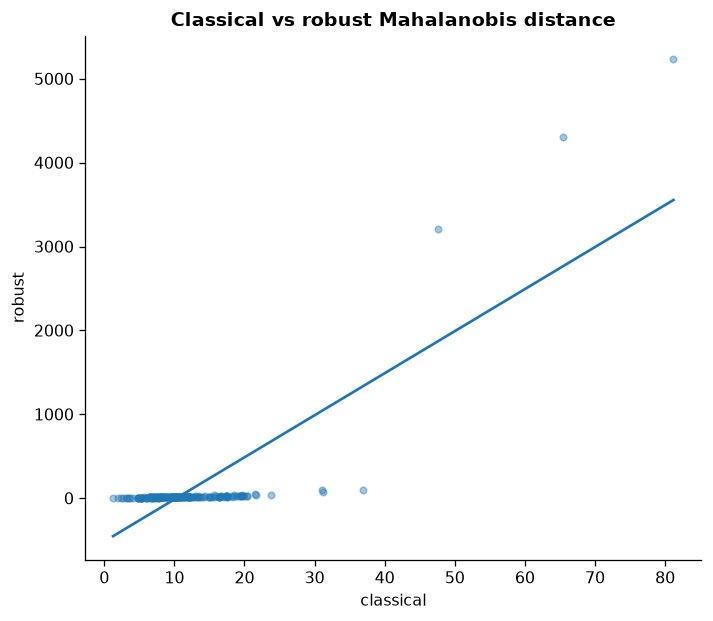

In [7]:
md=mv.mahalanobis.distances.query('status=="ok"').pivot(index='observation_id',columns='method',values='squared_distance').dropna(); ifcols=list(md.columns); distance_scatter(md[ifcols[0]].to_numpy(),md[ifcols[-1]].to_numpy(),title='Classical vs robust Mahalanobis distance',xlabel=str(ifcols[0]),ylabel=str(ifcols[-1])); plt.show()